### Configuración de Amazon Redshift Sin Servidor

Configuración de Amazon Redshift Sin Servidor: A continuación se presenta las configuraciones realizadas junto con las evidencias. 

#### Imagen del grupo de trabajo creado

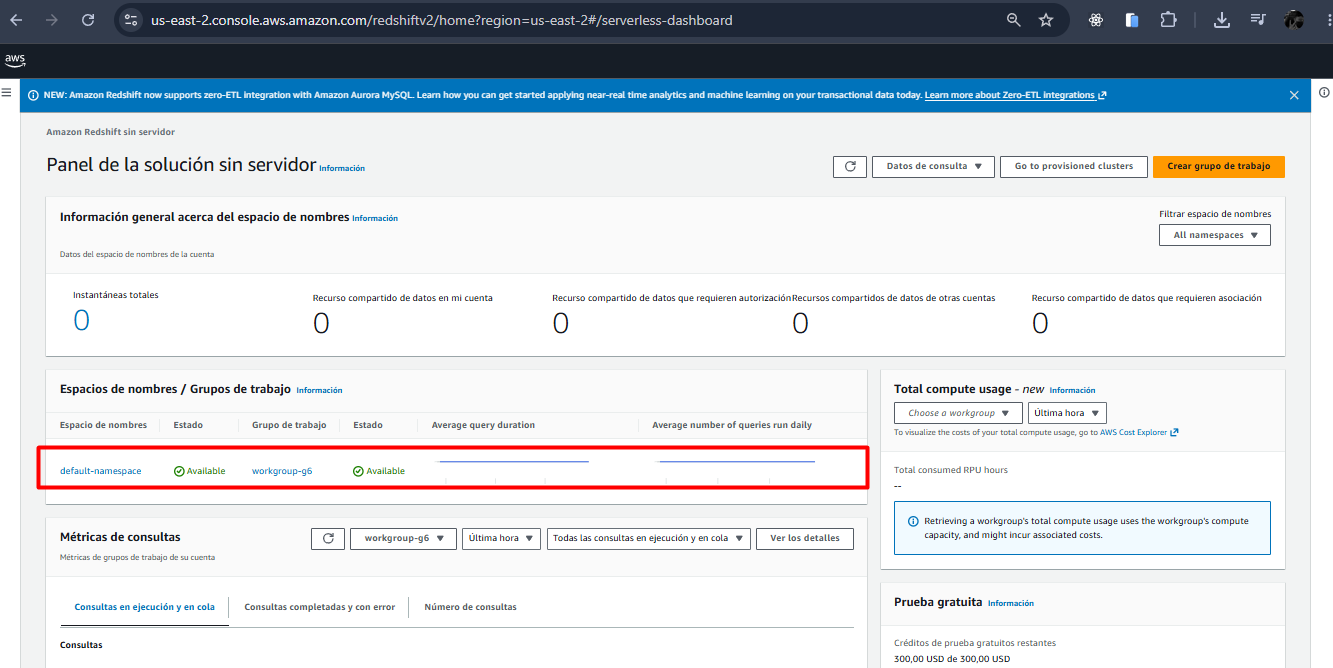

#### Imagen de la regla creada en el grupro de seguridad de la VPC

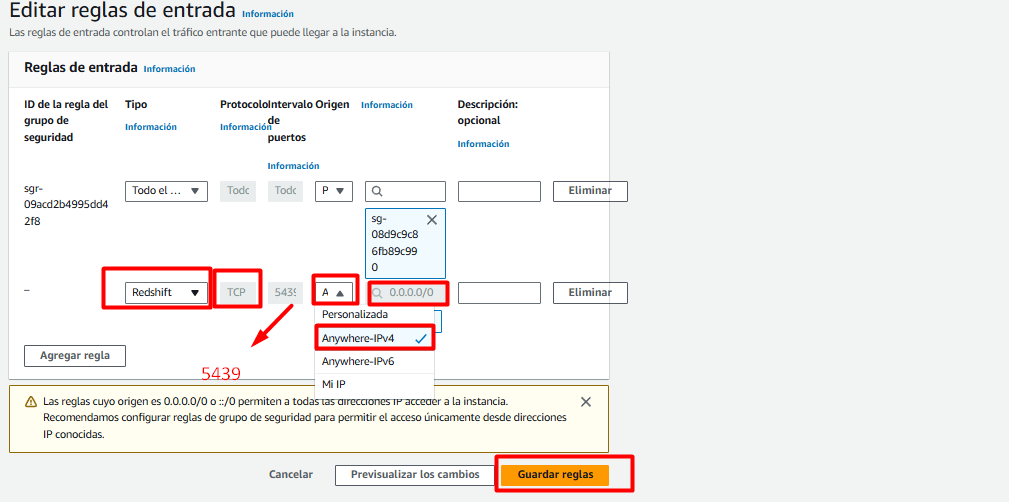

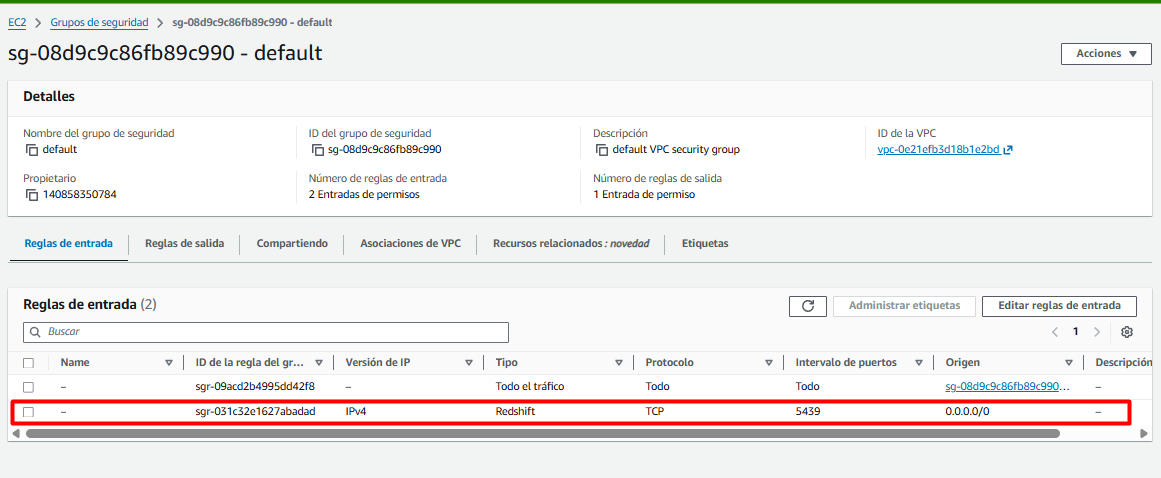

#### Configuración del Amazon S3

Creación de bucket (El nombre debe ser un nombre único y en minúsculas en esta caso es: bu-class-g6)


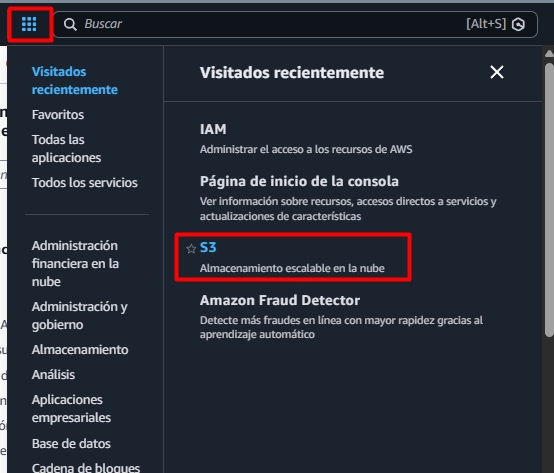

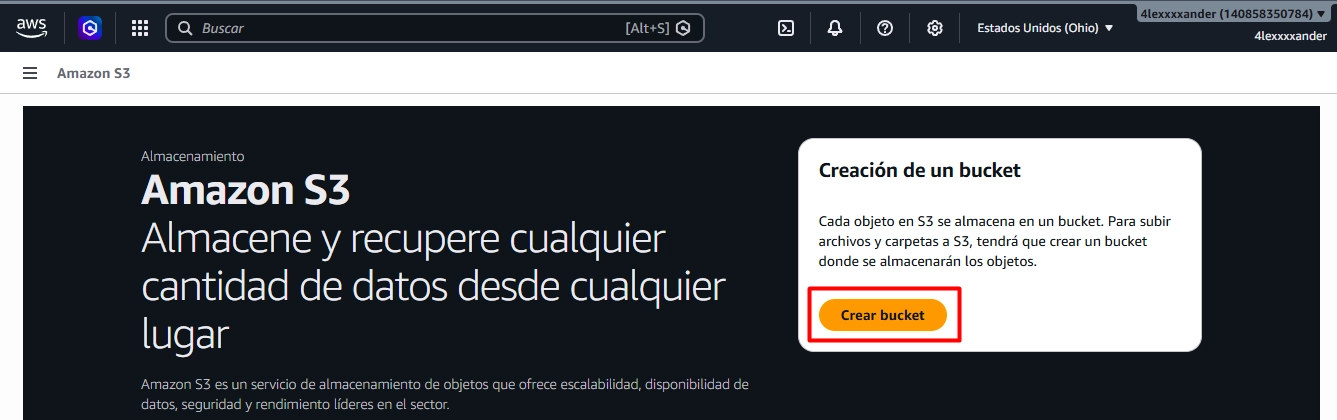

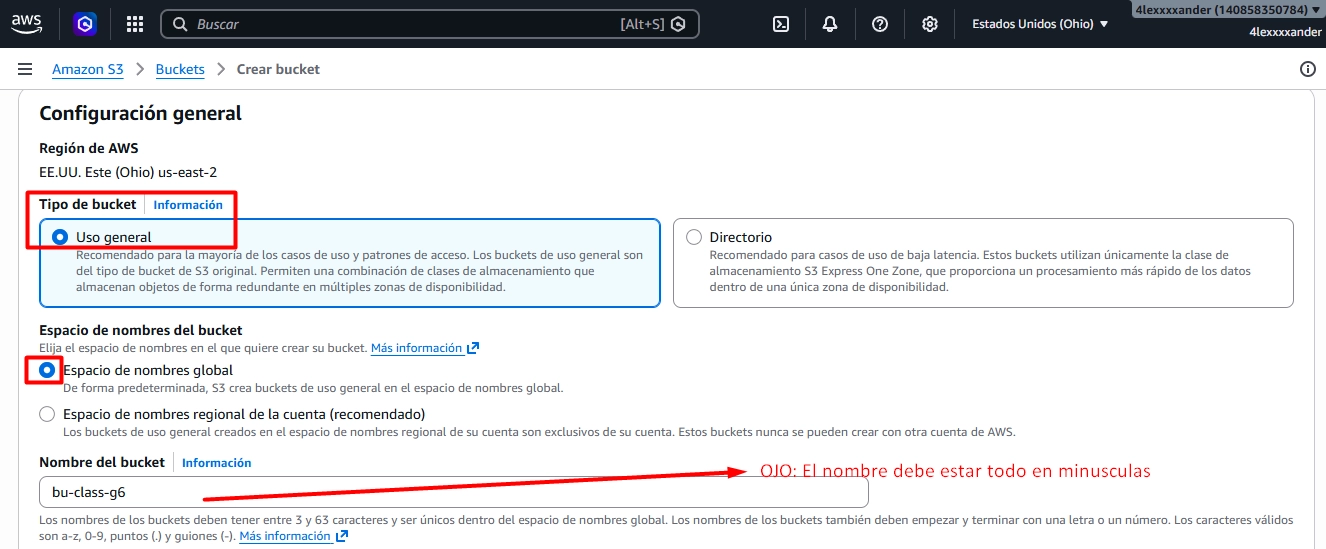

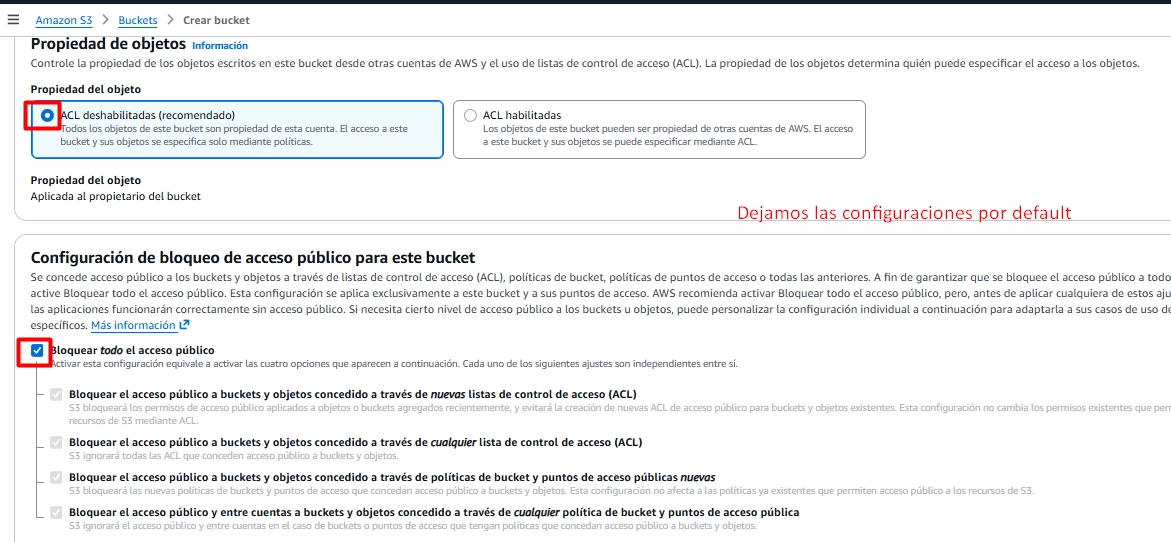

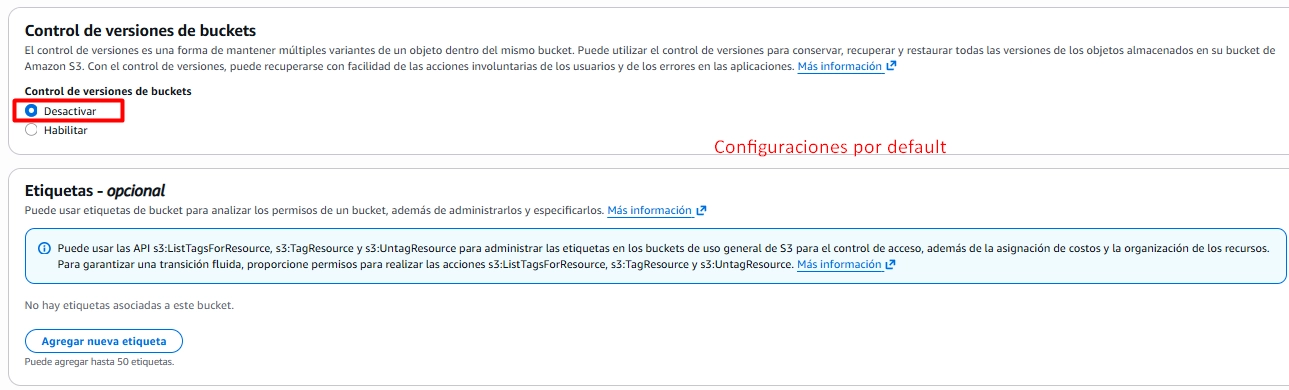

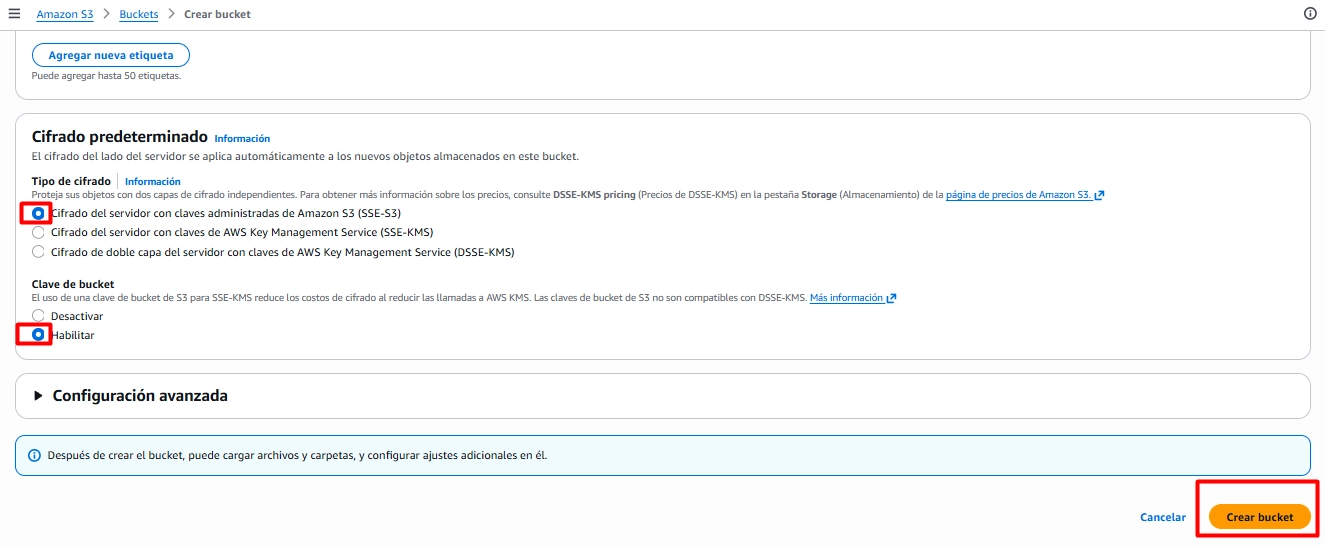

#### Imagen del S3 creado

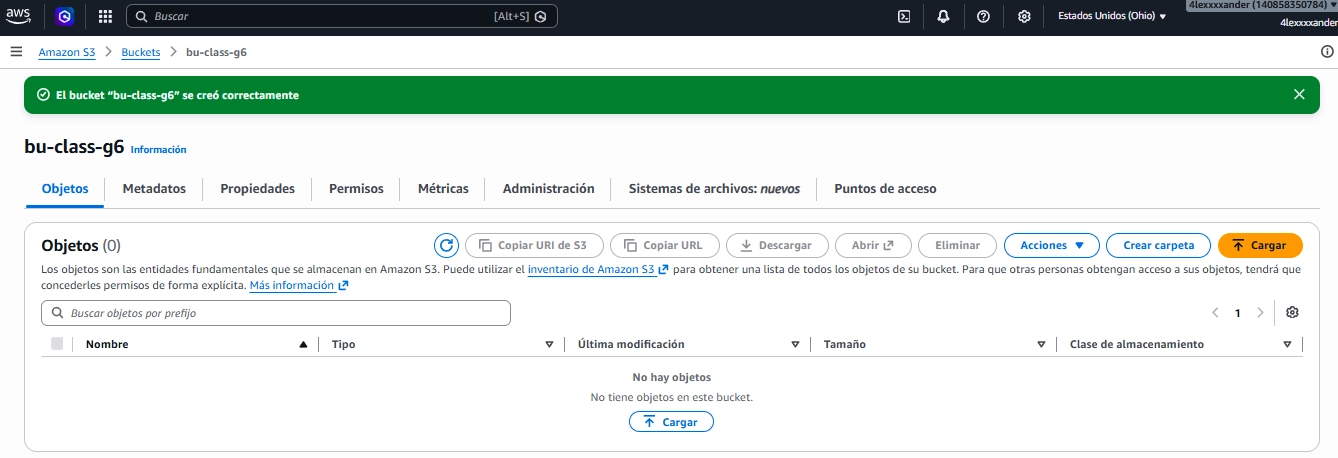

### Creación de conexión con AWS

Crear una la conexión a Amazon y a RedShift



Creación de la variables de entorno


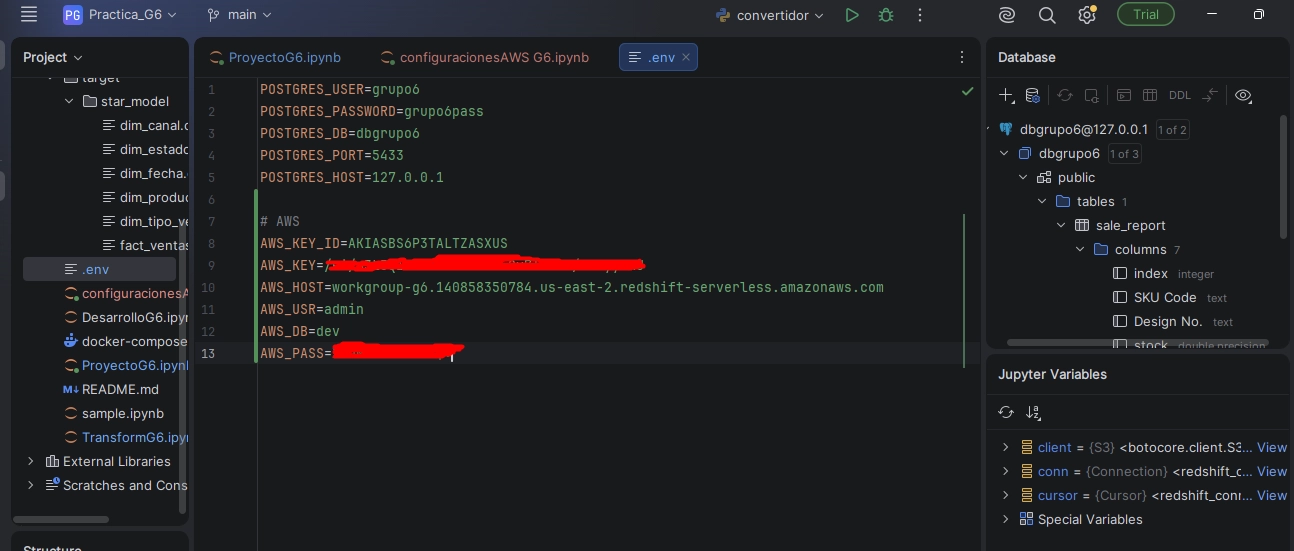

Creación de conexión

In [20]:
from dotenv import load_dotenv
import os
import boto3
import redshift_connector

load_dotenv()
client = boto3.client(
    's3',
    aws_access_key_id=os.getenv('AWS_KEY_ID'),
    aws_secret_access_key=os.getenv('AWS_KEY')
)

conn = redshift_connector.connect(
    host=os.getenv('AWS_HOST'),
    database=os.getenv('AWS_DB'),
    port=5439,
    user=os.getenv('AWS_USR'),
    password=os.getenv('AWS_PASS')
)

cursor = conn.cursor()

In [18]:
conn.close()

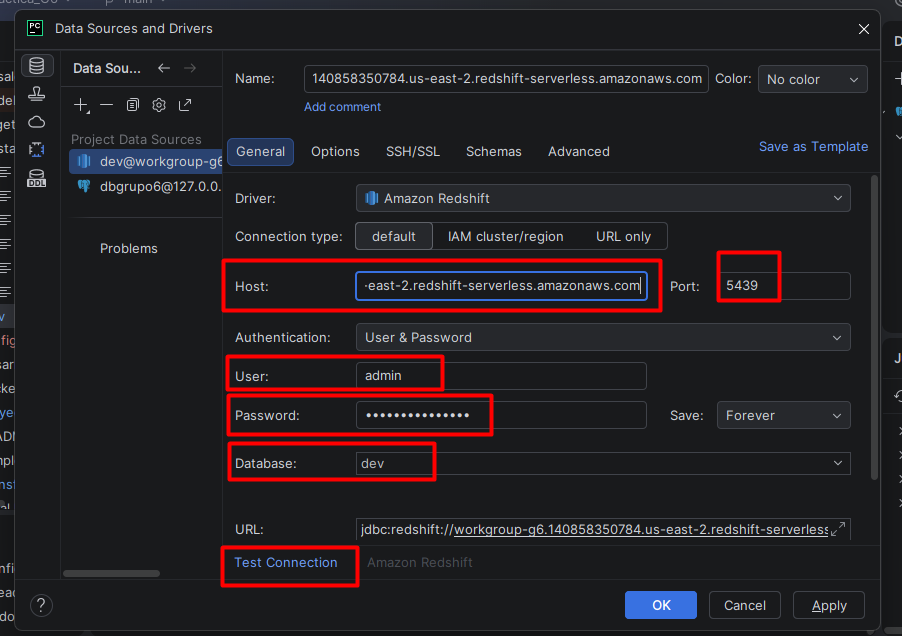

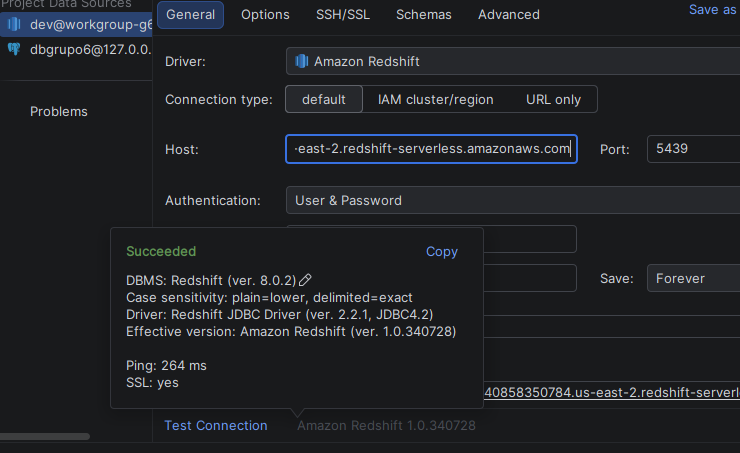

Crear una función load_file que permita realizar la carga de cada una las
dimensiones y la tabla de hechos del modelo


In [26]:
def load_file(file_name):
    table_name = file_name.split('.')[0]

    client.upload_file(
        Filename=f"target/star_model/{file_name}",
        Bucket="bu-class-g6",
        Key=f"etl_t/{file_name}",
    )

    sentence = """COPY public.{}
    FROM 's3://bu-class-g6/etl_t/{}'
    CREDENTIALS 'aws_access_key_id={};aws_secret_access_key={}'
    CSV
    DELIMITER ','
    REGION 'us-east-2'
    IGNOREHEADER 1
    EMPTYASNULL
    BLANKSASNULL;""".format(
        table_name,
        file_name,
        os.getenv("AWS_KEY_ID"),
        os.getenv("AWS_KEY")
    )

    try:
        cursor.execute(sentence)
        conn.commit()
        print('ok tabla ' + table_name)
    except Exception as e:
        print('error en la tabla:', e)

In [27]:
load_file('dim_canal.csv')

ok tabla dim_canal


In [28]:
load_file('dim_fecha.csv')
load_file('dim_producto.csv')
load_file('dim_tipo_venta.csv')
load_file('fact_ventas.csv')

ok tabla dim_fecha
ok tabla dim_producto
ok tabla dim_tipo_venta
ok tabla fact_ventas


Capturar el bucket con sus archivos cargados

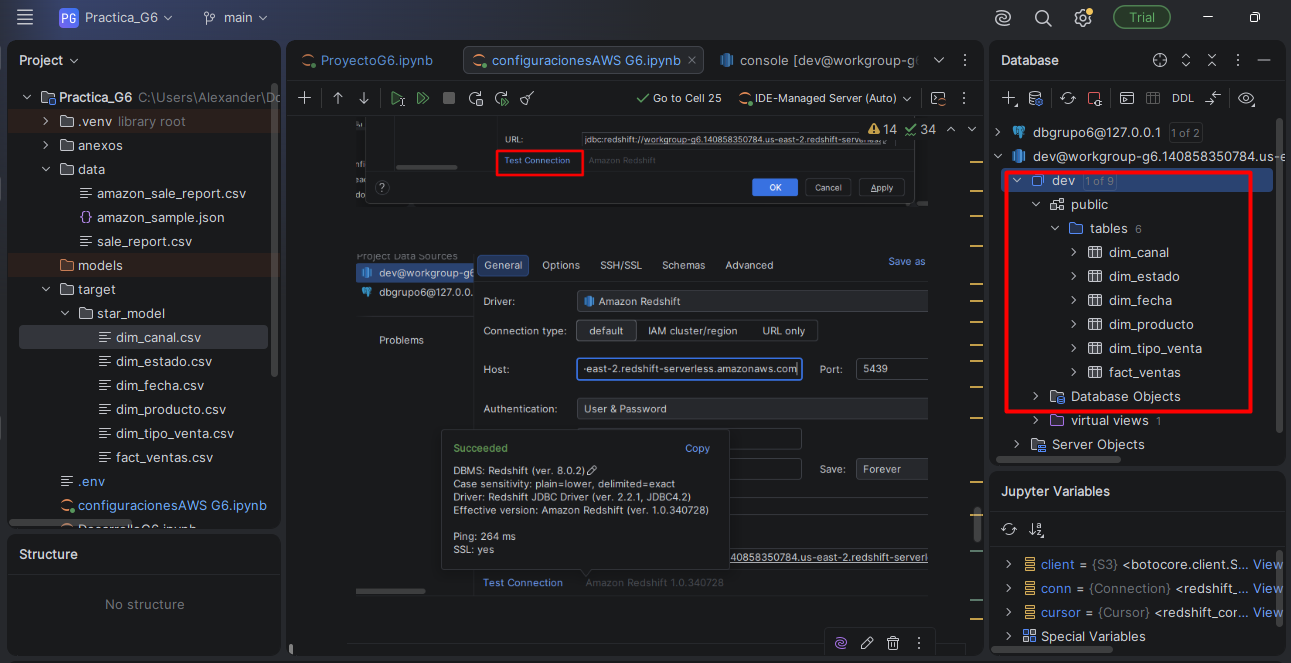

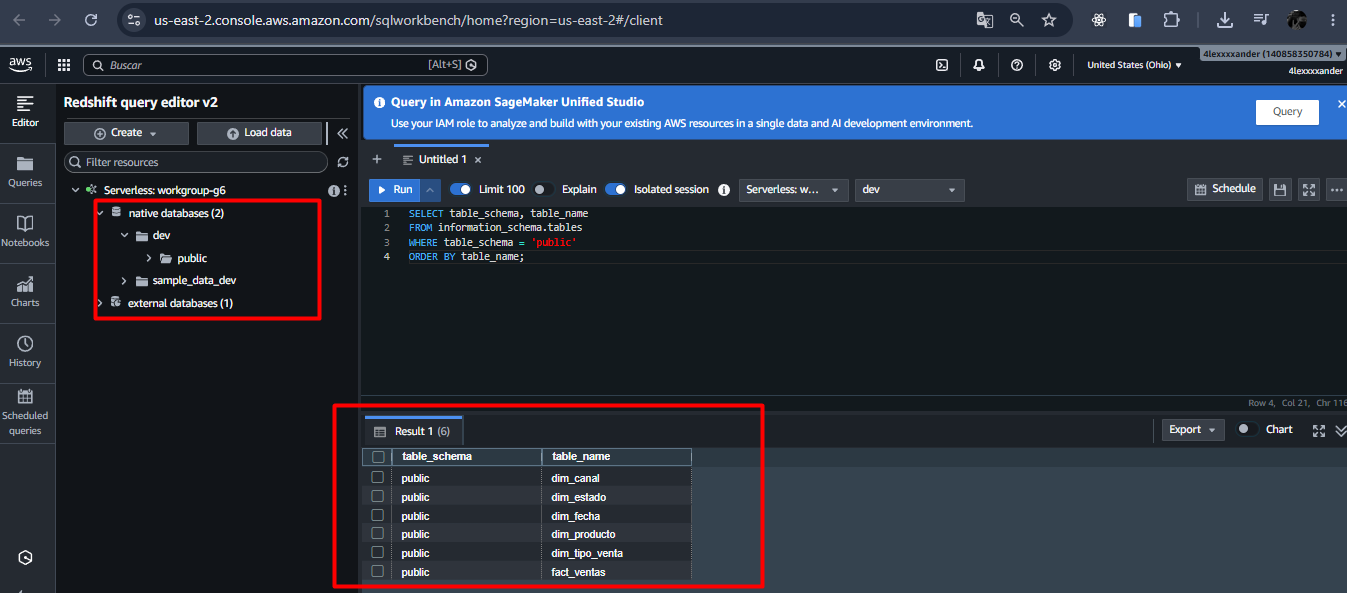

Evaluar el estado de carga de la información al cluster de redshift

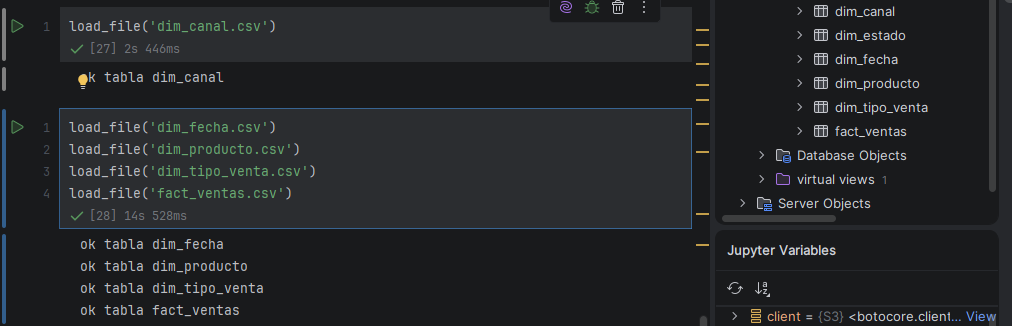

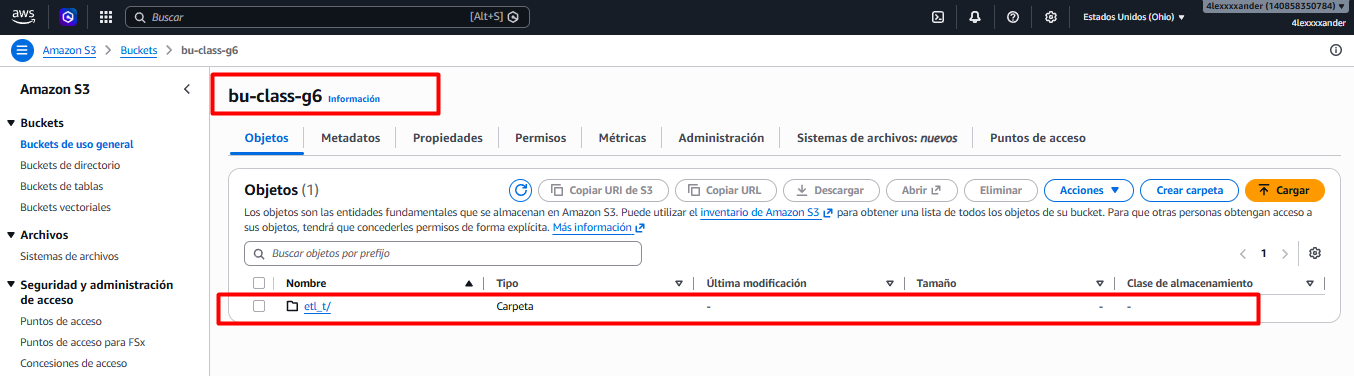

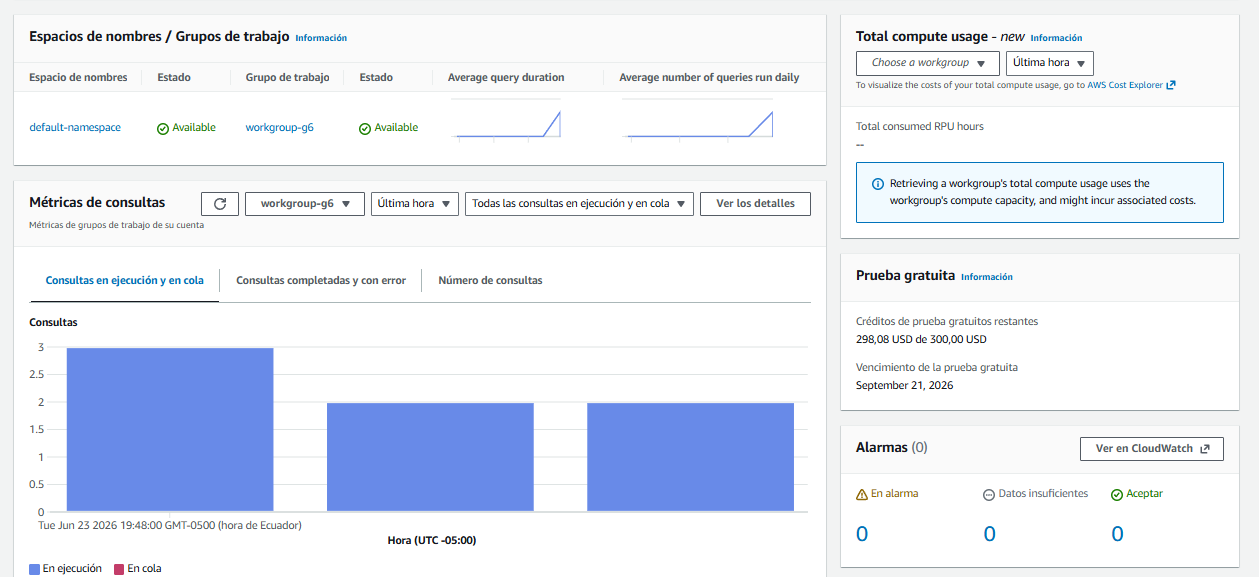

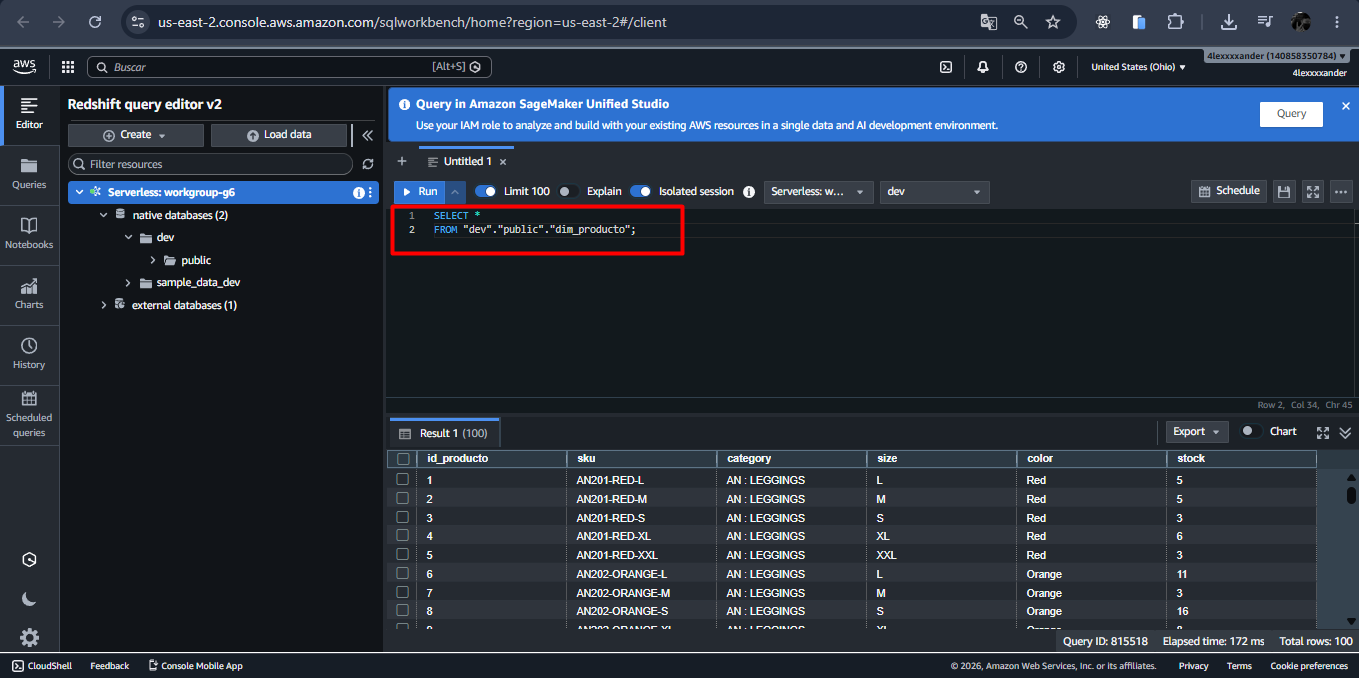